# Modeling - Churn Prediction

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate

X_train = joblib.load('data/warehouse/X_train_prepared.pkl')
y_train = joblib.load('data/warehouse/y_train.pkl')

print("Shape X_train:", X_train.shape)
print("Distribución target:\n", y_train.value_counts())
print(f"% Churn: {y_train.mean() * 100:.2f}%")

Shape X_train: (35982, 35)
Distribución target:
 Churn_400
0    32493
1     3489
Name: count, dtype: int64
% Churn: 9.70%


In [4]:
def display_scores(scores, metric='ROC-AUC'):
    print(f"  {metric} por fold: {scores.round(4)}")
    print(f"  Media:            {scores.mean():.4f}")
    print(f"  Std:              {scores.std():.4f}")

def plot_confusion_matrix(model, X, y, title):
    y_pred = cross_val_predict(model, X, y, cv=5)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print(classification_report(y, y_pred, target_names=['No Churn', 'Churn']))

def plot_roc_pr(model, X, y, title):
    y_scores = cross_val_predict(model, X, y, cv=5, method='predict_proba')[:, 1]

    fpr, tpr, _ = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)
    precisions, recalls, thresholds = precision_recall_curve(y, y_scores)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC
    axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'Curva ROC — {title}')
    axes[0].legend()
    axes[0].grid(True)

    # Precision-Recall vs Threshold
    axes[1].plot(thresholds, precisions[:-1], 'b-', label='Precision')
    axes[1].plot(thresholds, recalls[:-1],    'r-', label='Recall')
    axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Threshold=0.5')
    axes[1].set_xlabel('Threshold')
    axes[1].set_title(f'Precision & Recall vs Threshold — {title}')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_feature_importance(importances, feature_names, title, top_n=20):
    indices = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_importances, y=top_features, palette='Blues_r')
    plt.title(f'Top {top_n} Feature Importances — {title}')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()

feature_names = list(X_train.columns)

In [5]:
from sklearn.linear_model import LogisticRegression

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='roc_auc')
display_scores(scores)

LOGISTIC REGRESSION
  ROC-AUC por fold: [0.806  0.8063 0.809  0.8154 0.8085]
  Media:            0.8090
  Std:              0.0034


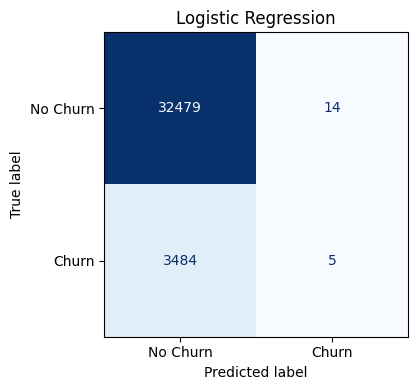

              precision    recall  f1-score   support

    No Churn       0.90      1.00      0.95     32493
       Churn       0.26      0.00      0.00      3489

    accuracy                           0.90     35982
   macro avg       0.58      0.50      0.48     35982
weighted avg       0.84      0.90      0.86     35982



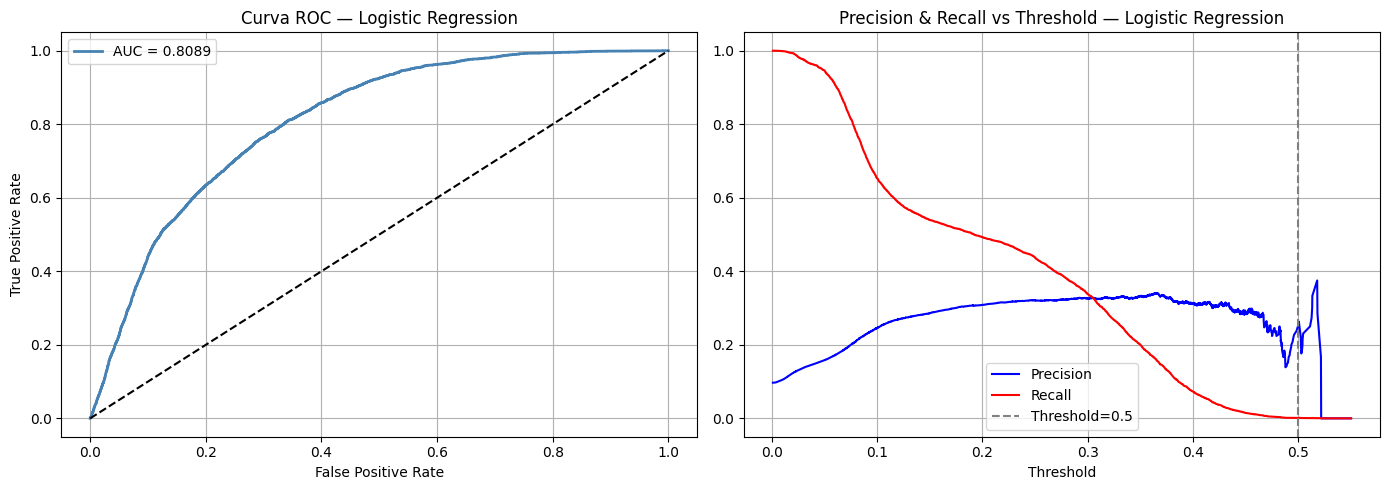

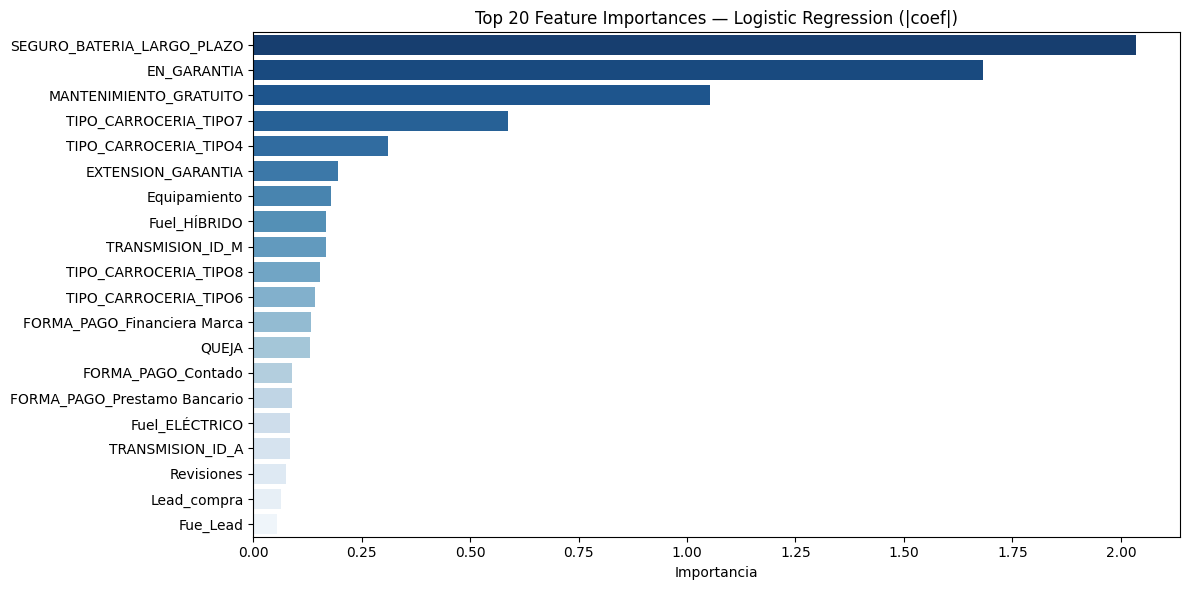

In [6]:
plot_confusion_matrix(log_reg, X_train, y_train, 'Logistic Regression')
plot_roc_pr(log_reg, X_train, y_train, 'Logistic Regression')

# Coeficientes como proxy de importancia
coef = np.abs(log_reg.coef_[0])
plot_feature_importance(coef, feature_names, 'Logistic Regression (|coef|)')

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("=" * 50)
print("DECISION TREE")
print("=" * 50)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

scores = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring='roc_auc')
display_scores(scores)

DECISION TREE
  ROC-AUC por fold: [0.6678 0.6676 0.6701 0.6727 0.6647]
  Media:            0.6686
  Std:              0.0027


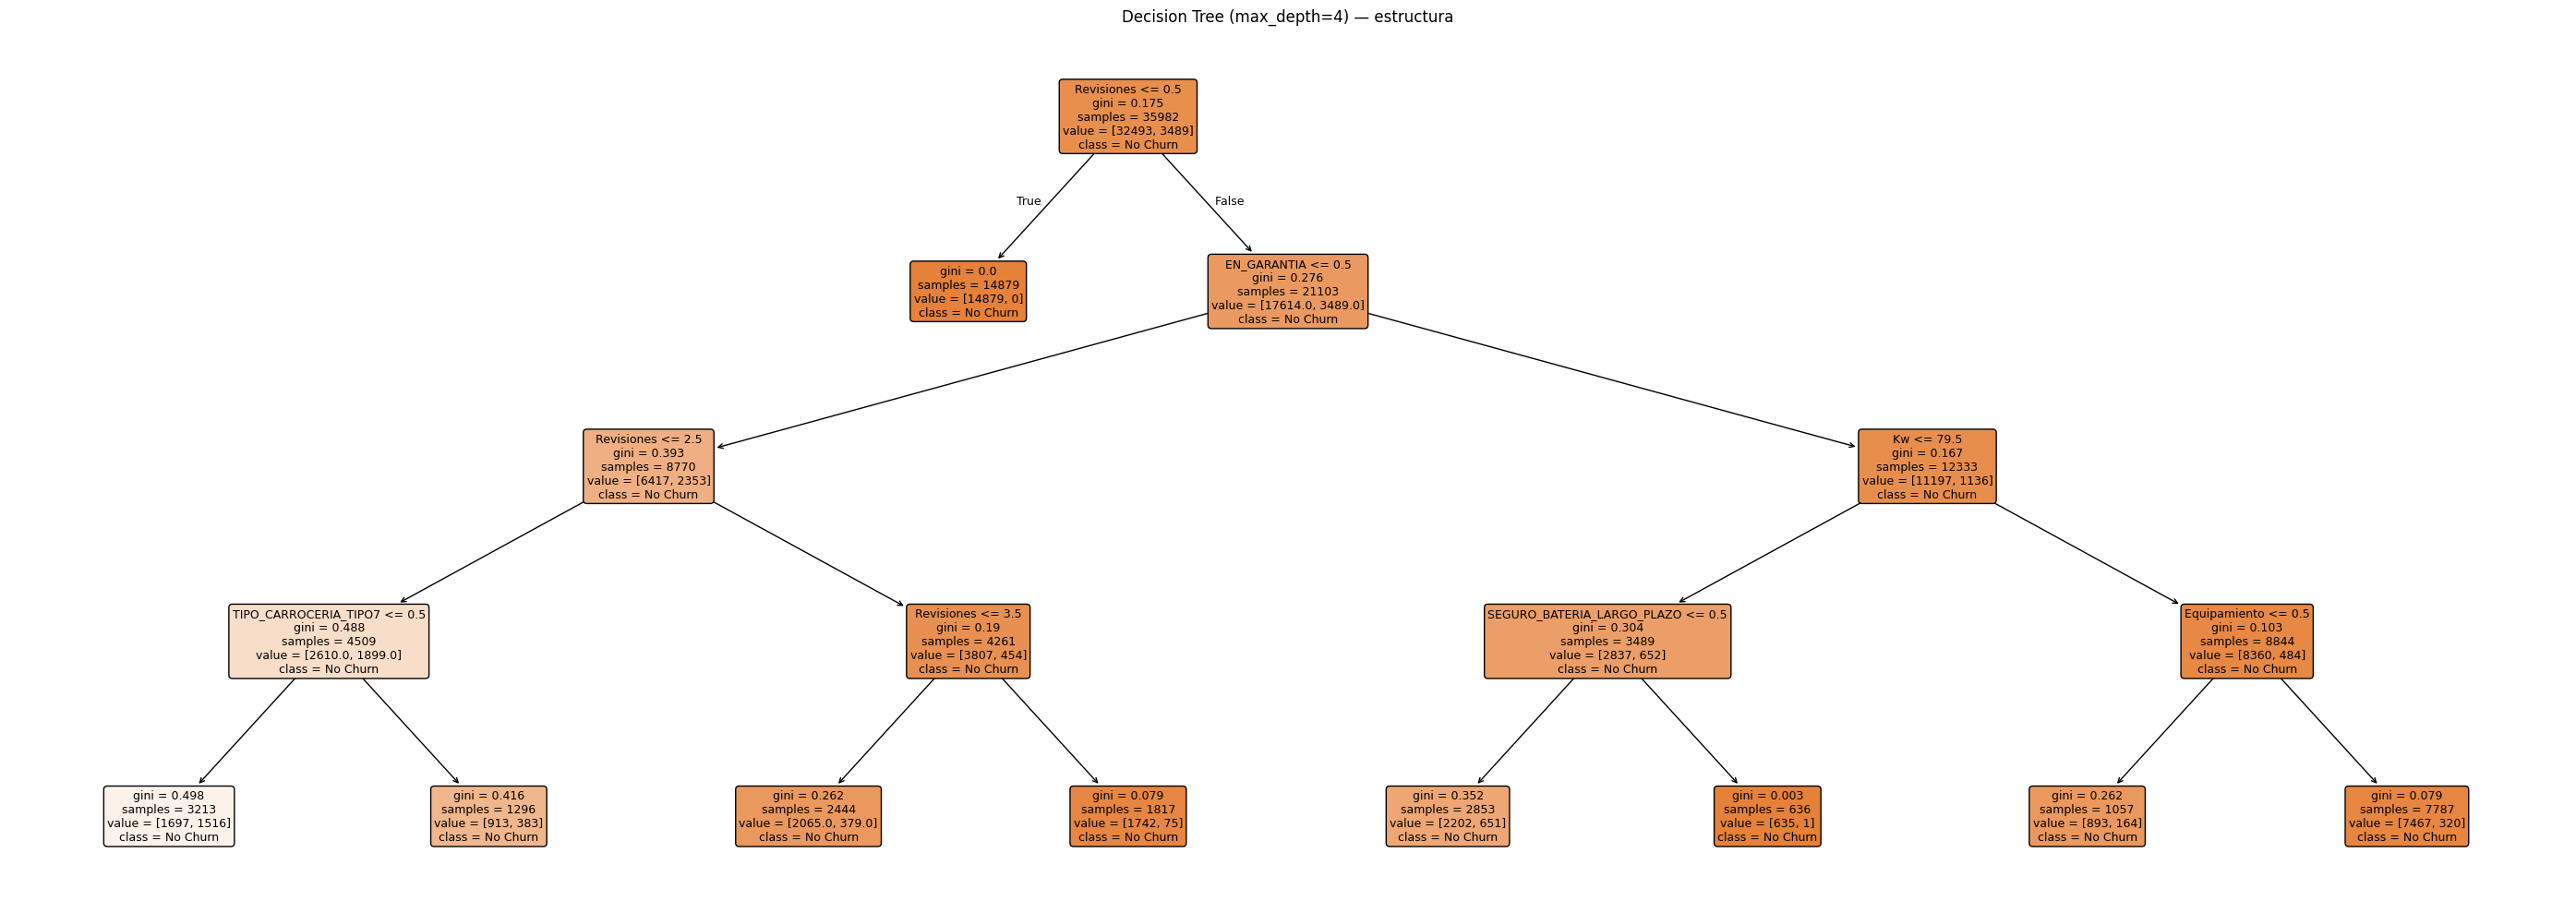

In [8]:
# Árbol simplificado para visualización
tree_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(28, 10))
plot_tree(
    tree_viz,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (max_depth=4) — estructura')
plt.tight_layout()
plt.show()

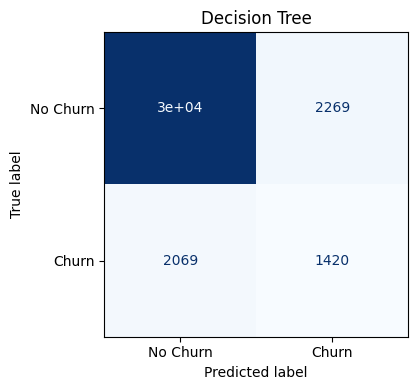

              precision    recall  f1-score   support

    No Churn       0.94      0.93      0.93     32493
       Churn       0.38      0.41      0.40      3489

    accuracy                           0.88     35982
   macro avg       0.66      0.67      0.66     35982
weighted avg       0.88      0.88      0.88     35982



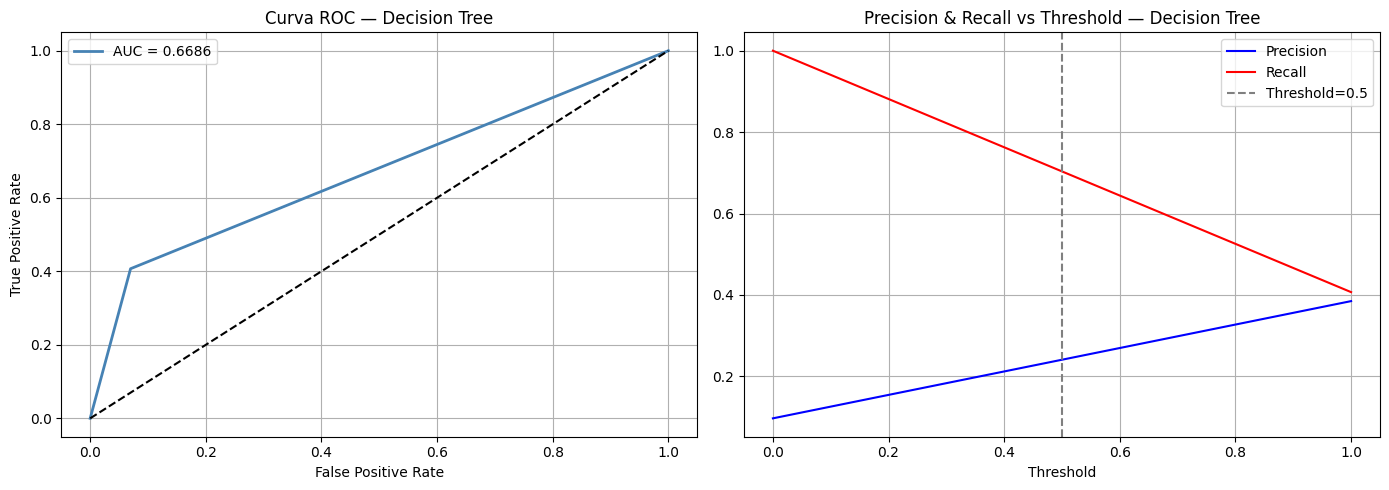

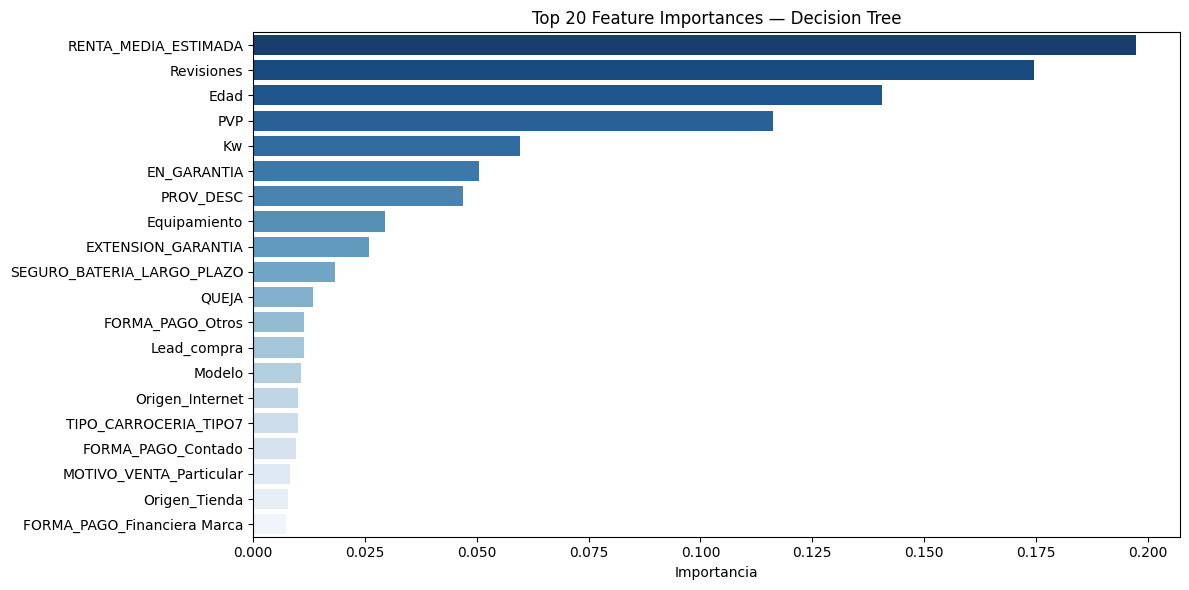

In [9]:
plot_confusion_matrix(tree_clf, X_train, y_train, 'Decision Tree')
plot_roc_pr(tree_clf, X_train, y_train, 'Decision Tree')
plot_feature_importance(tree_clf.feature_importances_, feature_names, 'Decision Tree')

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = [
    {'max_depth': [3, 5, 10, None],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4],
     'class_weight': [None, 'balanced']}
]

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, cv=5,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1, verbose=1
)
grid_tree.fit(X_train, y_train)

print("Mejores parámetros:", grid_tree.best_params_)
print(f"Mejor ROC-AUC (val): {grid_tree.best_score_:.4f}")

# Comparativa train vs val para detectar overfitting
cv_results = pd.DataFrame(grid_tree.cv_results_)
print(f"\nMejor Train ROC-AUC: {cv_results.loc[grid_tree.best_index_, 'mean_train_score']:.4f}")
print(f"Mejor Val   ROC-AUC: {cv_results.loc[grid_tree.best_index_, 'mean_test_score']:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor ROC-AUC (val): 0.8995

Mejor Train ROC-AUC: 0.9378
Mejor Val   ROC-AUC: 0.8995


In [11]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest_clf.fit(X_train, y_train)

scores = cross_val_score(forest_clf, X_train, y_train, cv=5, scoring='roc_auc')
display_scores(scores)

RANDOM FOREST
  ROC-AUC por fold: [0.8928 0.9036 0.9041 0.9051 0.8997]
  Media:            0.9011
  Std:              0.0045


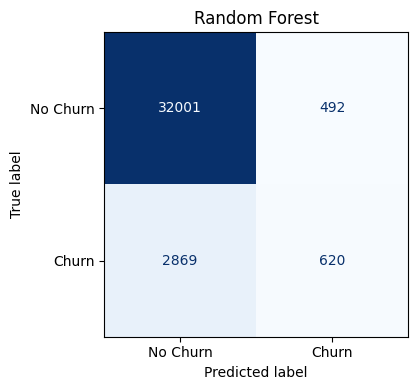

              precision    recall  f1-score   support

    No Churn       0.92      0.98      0.95     32493
       Churn       0.56      0.18      0.27      3489

    accuracy                           0.91     35982
   macro avg       0.74      0.58      0.61     35982
weighted avg       0.88      0.91      0.88     35982



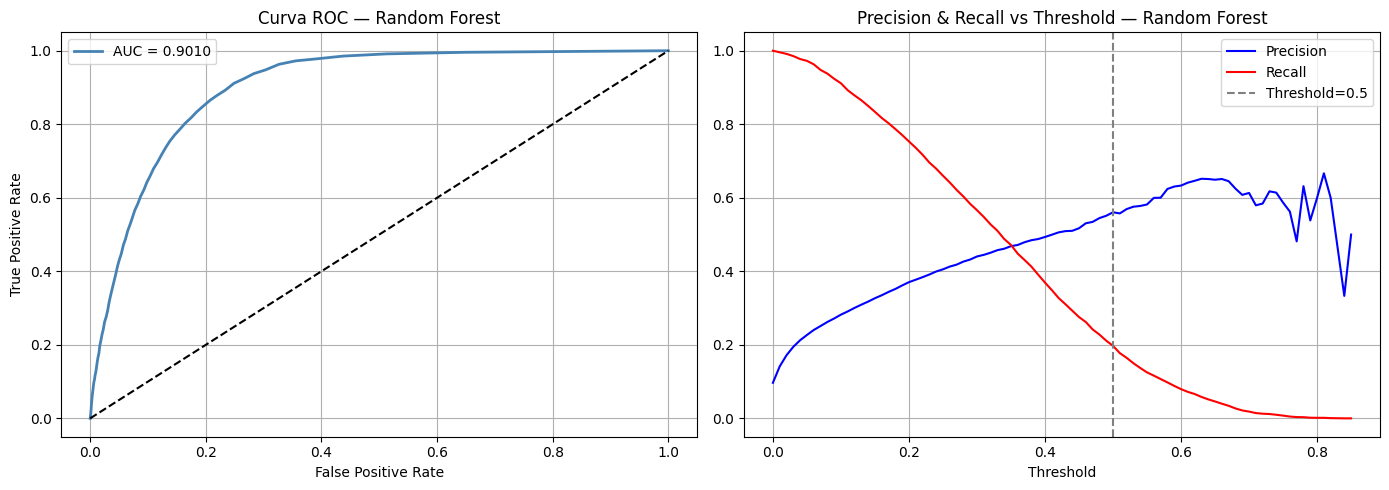

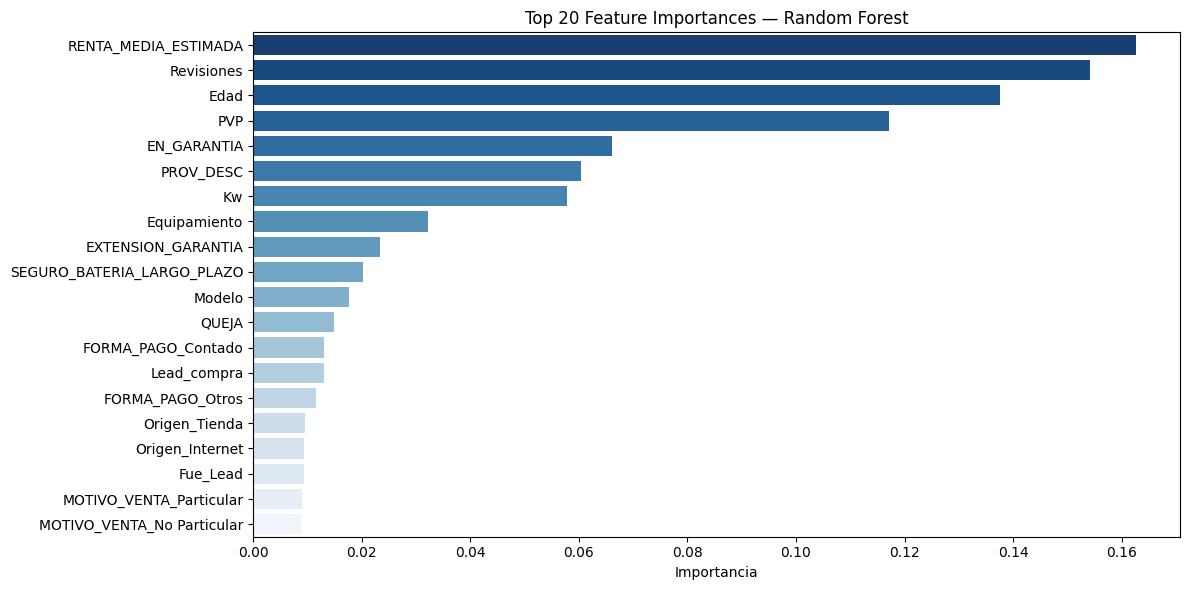

In [12]:
plot_confusion_matrix(forest_clf, X_train, y_train, 'Random Forest')
plot_roc_pr(forest_clf, X_train, y_train, 'Random Forest')
plot_feature_importance(forest_clf.feature_importances_, feature_names, 'Random Forest')

/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

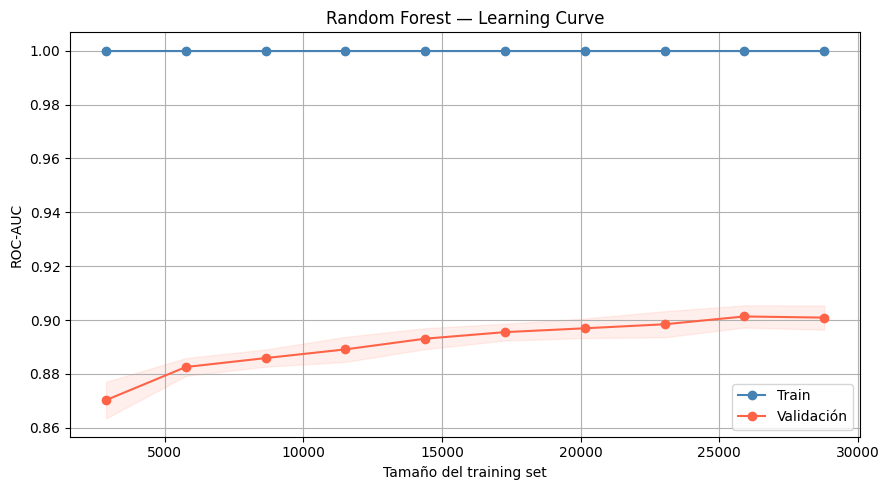

In [13]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_scores.mean(1), 'o-', label='Train', color='steelblue')
    plt.plot(train_sizes, val_scores.mean(1),   'o-', label='Validación', color='tomato')
    plt.fill_between(train_sizes,
                     train_scores.mean(1) - train_scores.std(1),
                     train_scores.mean(1) + train_scores.std(1), alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes,
                     val_scores.mean(1) - val_scores.std(1),
                     val_scores.mean(1) + val_scores.std(1), alpha=0.1, color='tomato')
    plt.xlabel('Tamaño del training set')
    plt.ylabel('ROC-AUC')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_learning_curve(forest_clf, X_train, y_train, 'Random Forest — Learning Curve')

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_forest = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None],
    'class_weight':      [None, 'balanced'],
}

rnd_forest = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_forest,
    n_iter=20, cv=5,
    scoring='roc_auc',
    return_train_score=True,
    random_state=42, n_jobs=-1, verbose=1
)
rnd_forest.fit(X_train, y_train)

print("Mejores parámetros:", rnd_forest.best_params_)
print(f"Mejor ROC-AUC (val): {rnd_forest.best_score_:.4f}")

cv_results = pd.DataFrame(rnd_forest.cv_results_)
print(f"\nMejor Train ROC-AUC: {cv_results.loc[rnd_forest.best_index_, 'mean_train_score']:.4f}")
print(f"Mejor Val   ROC-AUC: {cv_results.loc[rnd_forest.best_index_, 'mean_test_score']:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10, 'class_weight': None}
Mejor ROC-AUC (val): 0.9200

Mejor Train ROC-AUC: 0.9525
Mejor Val   ROC-AUC: 0.9200


In [15]:
from xgboost import XGBClassifier

print("=" * 50)
print("XGBOOST")
print("=" * 50)

xgb_clf = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

scores = cross_val_score(xgb_clf, X_train, y_train, cv=5, scoring='roc_auc')
display_scores(scores)

XGBOOST
  ROC-AUC por fold: [0.9072 0.9177 0.9092 0.9145 0.9148]
  Media:            0.9127
  Std:              0.0039


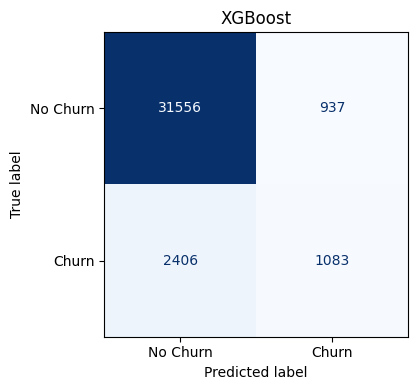

              precision    recall  f1-score   support

    No Churn       0.93      0.97      0.95     32493
       Churn       0.54      0.31      0.39      3489

    accuracy                           0.91     35982
   macro avg       0.73      0.64      0.67     35982
weighted avg       0.89      0.91      0.90     35982



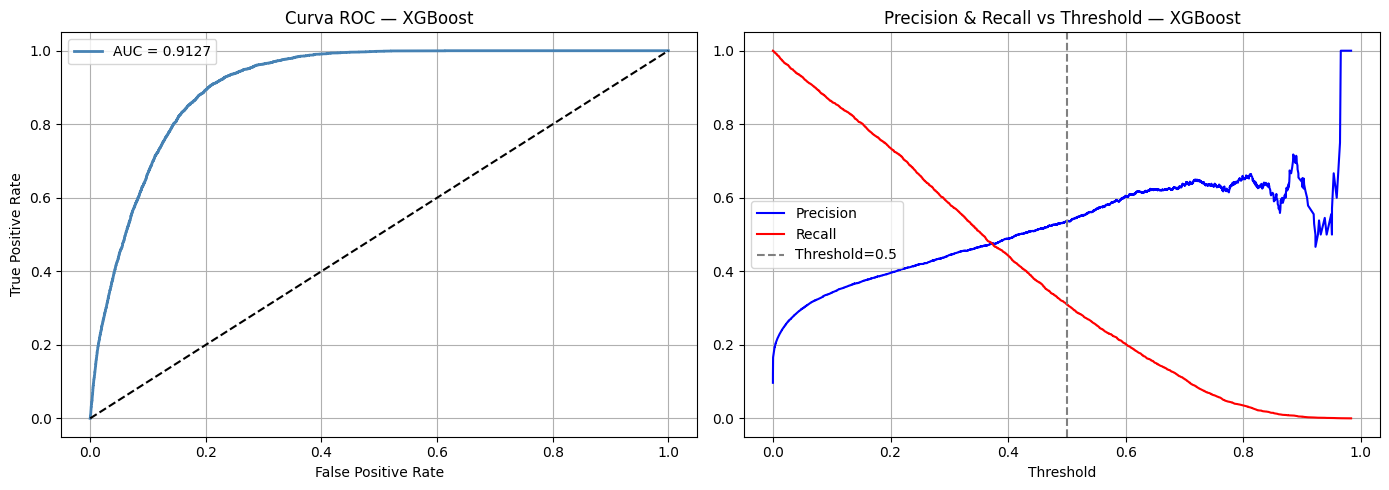

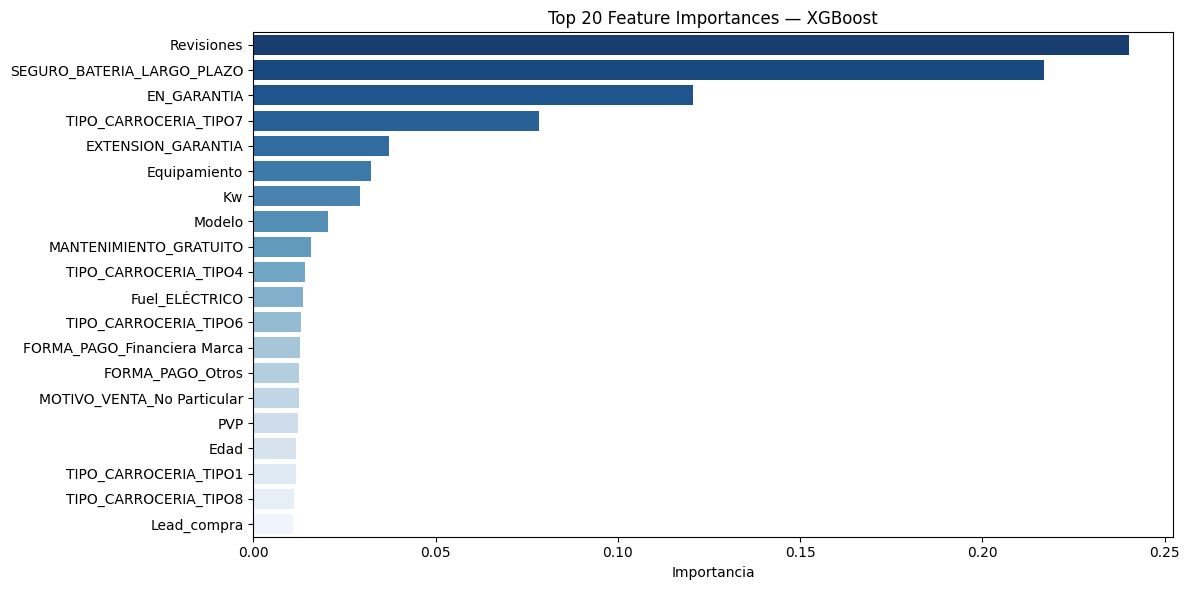

In [16]:
plot_confusion_matrix(xgb_clf, X_train, y_train, 'XGBoost')
plot_roc_pr(xgb_clf, X_train, y_train, 'XGBoost')
plot_feature_importance(xgb_clf.feature_importances_, feature_names, 'XGBoost')

In [17]:
param_dist_xgb = {
    'n_estimators':   [100, 200, 300],
    'max_depth':      [3, 5, 7, 9],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, y_train.value_counts()[0] / y_train.value_counts()[1]],  # maneja desbalance
}

rnd_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  eval_metric='logloss', n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=20, cv=5,
    scoring='roc_auc',
    return_train_score=True,
    random_state=42, n_jobs=-1, verbose=1
)
rnd_xgb.fit(X_train, y_train)

print("Mejores parámetros:", rnd_xgb.best_params_)
print(f"Mejor ROC-AUC (val): {rnd_xgb.best_score_:.4f}")

cv_results = pd.DataFrame(rnd_xgb.cv_results_)
print(f"\nMejor Train ROC-AUC: {cv_results.loc[rnd_xgb.best_index_, 'mean_train_score']:.4f}")
print(f"Mejor Val   ROC-AUC: {cv_results.loc[rnd_xgb.best_index_, 'mean_test_score']:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Mejor ROC-AUC (val): 0.9213

Mejor Train ROC-AUC: 0.9374
Mejor Val   ROC-AUC: 0.9213


In [22]:
best_models = {
    'Logistic Regression': log_reg,
    'Decision Tree':       grid_tree.best_estimator_,
    'Random Forest':       rnd_forest.best_estimator_,
    'XGBoost':             rnd_xgb.best_estimator_,
}

results = []
for name, model in best_models.items():
    cv = cross_validate(model, X_train, y_train, cv=5,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'],
                        return_train_score=True)
    results.append({
        'Modelo':        name,
        'Train AUC':     cv['train_roc_auc'].mean().round(4),
        'Val AUC':       cv['test_roc_auc'].mean().round(4),
        'Val F1':        cv['test_f1'].mean().round(4),
        'Val Precision': cv['test_precision'].mean().round(4),
        'Val Recall':    cv['test_recall'].mean().round(4),
        'Std AUC':       cv['test_roc_auc'].std().round(4),
    })

df_results = pd.DataFrame(results).set_index('Modelo')
df_results['Overfit'] = (df_results['Train AUC'] - df_results['Val AUC']).round(4)
display(df_results.sort_values('Val AUC', ascending=False))

,Train AUC,Val AUC,Val F1,Val Precision,Val Recall,Std AUC,Overfit
Modelo,,,,,,,
XGBoost,0.9374,0.9213,0.3022,0.6722,0.1952,0.0030,0.0161
Random Forest,0.9525,0.9200,0.3788,0.6233,0.2723,0.0034,0.0325
Decision Tree,0.9378,0.8995,0.3736,0.5610,0.2803,0.0060,0.0383
Logistic Regression,0.8112,0.8090,0.0028,0.1857,0.0014,0.0034,0.0022


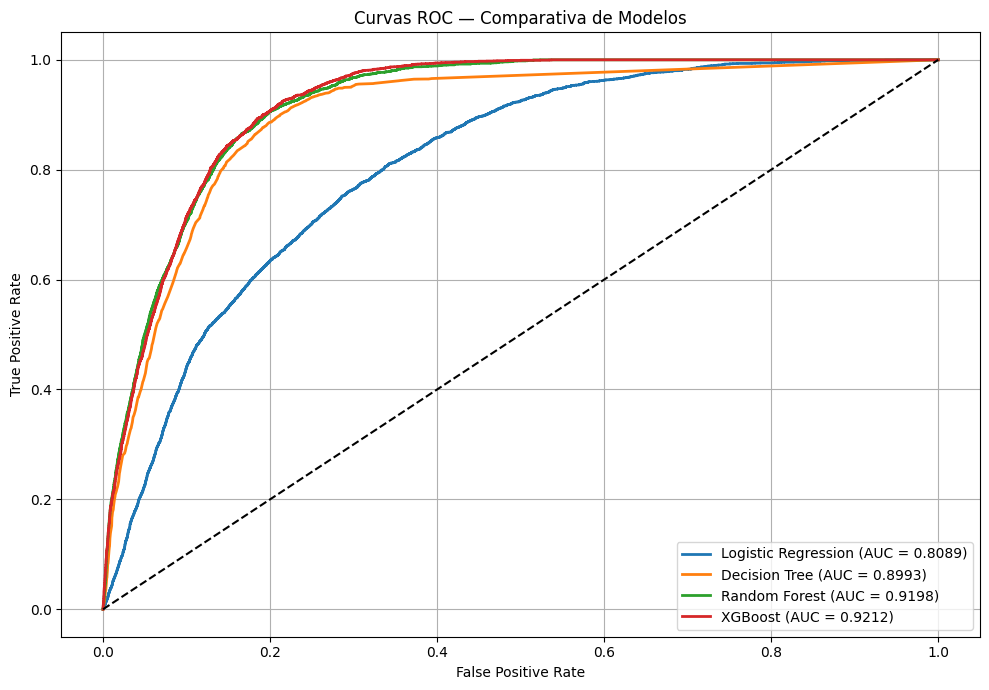

In [23]:
plt.figure(figsize=(10, 7))

for name, model in best_models.items():
    y_scores = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC — Comparativa de Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
for name, model in best_models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'data/warehouse/{filename}.pkl')
    print(f"Guardado: {filename}.pkl ✓")

Guardado: logistic_regression.pkl ✓
Guardado: decision_tree.pkl ✓
Guardado: random_forest.pkl ✓
Guardado: xgboost.pkl ✓
